<a href="https://colab.research.google.com/github/silver-maple/colab/blob/main/time_series_with_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet

In [2]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
n = 365

In [5]:
dates = pd.date_range(start='2023-01-01', periods=n, freq='D')

In [6]:
seasonal_effect = 10 * np.sin(np.linspace(0, 2 * np.pi, n))

In [7]:
noise = np.random.normal(0, 5, size=n)

In [8]:
trend = np.linspace(50, 200, n)

In [9]:
holiday_effect = np.random.choice([0, 1], size=n, p=[0.9, 0.1])

In [10]:
sales = trend + seasonal_effect + noise + holiday_effect * 30

In [12]:
df = pd.DataFrame({
    'date': dates,
    'sales': sales,
    'holiday_effect': holiday_effect
})

In [13]:
df.head()

,date,sales,holiday_effect
0,2023-01-01,44.440562,0
1,2023-01-02,52.485223,0
2,2023-01-03,49.348083,0
3,2023-01-04,54.830705,0
4,2023-01-05,49.751864,0


In [16]:
df_prophet = df[["date", "sales"]].rename(columns = {"date":"ds", "sales":"y"})

In [18]:
df_prophet.tail()

,ds,y
360,2023-12-27,204.160159
361,2023-12-28,195.542543
362,2023-12-29,192.044006
363,2023-12-30,200.570460
364,2023-12-31,205.096553


In [19]:
model = Prophet()

In [20]:
model.fit(df_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [21]:
future_dates = pd.date_range(start="2024-01-01", periods=30, freq="D")

In [22]:
future_df = pd.DataFrame({"ds": future_dates})

In [24]:
future_df.tail()

,ds
25,2024-01-26
26,2024-01-27
27,2024-01-28
28,2024-01-29
29,2024-01-30


In [25]:
forecast = model.predict(future_df)

In [29]:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-01-01,201.019641,185.889528,215.406787
1,2024-01-02,198.687456,184.411050,212.367001
2,2024-01-03,198.729699,183.906150,213.789001
3,2024-01-04,198.046617,184.480392,211.918003
4,2024-01-05,199.353983,185.594666,213.823139


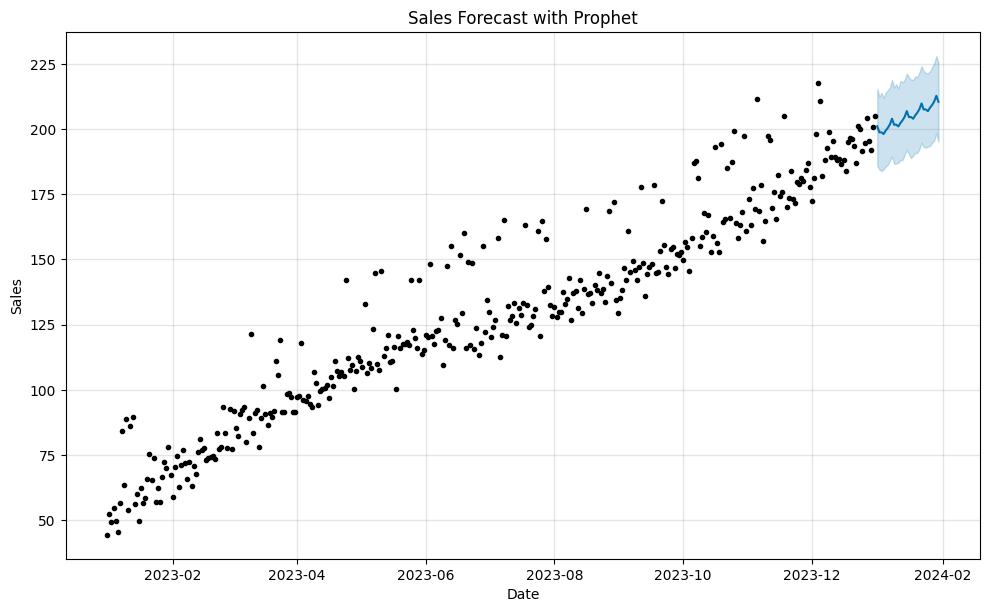

In [31]:
model.plot(forecast)
plt.title("Sales Forecast with Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [32]:
import pickle

with open("prophet_model.pkl", "wb") as f:
  pickle.dump(model, f)